In [47]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)


In [48]:
# Make sure the CSV file is in the same folder
# The previous error occurred because '/content/sample_data' is a directory, not a CSV file.
# We need to specify the full path to an actual CSV file within that directory.
df = pd.read_csv("/content/sample_data/california_housing_train.csv")

print("Dataset loaded successfully")
print(df.head())

Dataset loaded successfully
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -114.31     34.19                15.0       5612.0          1283.0   
1    -114.47     34.40                19.0       7650.0          1901.0   
2    -114.56     33.69                17.0        720.0           174.0   
3    -114.57     33.64                14.0       1501.0           337.0   
4    -114.57     33.57                20.0       1454.0           326.0   

   population  households  median_income  median_house_value  
0      1015.0       472.0         1.4936             66900.0  
1      1129.0       463.0         1.8200             80100.0  
2       333.0       117.0         1.6509             85700.0  
3       515.0       226.0         3.1917             73400.0  
4       624.0       262.0         1.9250             65500.0  


In [49]:
# Remove rows with missing essential values
# The KeyError occurred because 'Crime type', 'Latitude', and 'Longitude' are not valid column names in the current DataFrame.
# Based on the previous df.head() output, the columns are 'longitude' and 'latitude' (lowercase).
# 'Crime type' does not exist in this dataset.
df = df.dropna(subset=["latitude", "longitude"])

print("Data cleaned")
print("Total records after cleaning:", len(df))

Data cleaned
Total records after cleaning: 17000


In [50]:
X = df[["latitude", "longitude"]]   # Features
y = df["median_house_value"]                # Target

In [51]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

print("Crime categories:")
print(list(encoder.classes_))


Crime categories:
[np.float64(14999.0), np.float64(17500.0), np.float64(22500.0), np.float64(25000.0), np.float64(26600.0), np.float64(26900.0), np.float64(27500.0), np.float64(28300.0), np.float64(30000.0), np.float64(32500.0), np.float64(32900.0), np.float64(34200.0), np.float64(34400.0), np.float64(34600.0), np.float64(35000.0), np.float64(36600.0), np.float64(36700.0), np.float64(37500.0), np.float64(37900.0), np.float64(38800.0), np.float64(39400.0), np.float64(39600.0), np.float64(40000.0), np.float64(40400.0), np.float64(40900.0), np.float64(41000.0), np.float64(41300.0), np.float64(41400.0), np.float64(41700.0), np.float64(41800.0), np.float64(42100.0), np.float64(42500.0), np.float64(42600.0), np.float64(42700.0), np.float64(43000.0), np.float64(43100.0), np.float64(43300.0), np.float64(43500.0), np.float64(43600.0), np.float64(43700.0), np.float64(43800.0), np.float64(43900.0), np.float64(44000.0), np.float64(44100.0), np.float64(44400.0), np.float64(44500.0), np.float64(4460

In [52]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))


Training samples: 13600
Testing samples: 3400


In [53]:

# The current dataset (California Housing) contains no 'object' dtype columns
# that need LabelEncoding for features or target.
encoders = {}

X = df[features]

# Handle the target variable, which is continuous. For classification,
# we need to discretize it first to allow for stratification.
y_binned = pd.qcut(df[target], q=5, labels=False, duplicates='drop')
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y_binned)

In [54]:
#  Train / test split
# -----------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

In [55]:
#  Train Random Forest
# -----------------------------
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=200, n_jobs=-1, random_state=42)

In [56]:
y_pred = rf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))


Accuracy: 0.6420588235294118

Classification Report:

              precision    recall  f1-score   support

           0       0.77      0.83      0.80       681
           1       0.58      0.57      0.57       680
           2       0.55      0.55      0.55       680
           3       0.56      0.56      0.56       679
           4       0.75      0.70      0.72       680

    accuracy                           0.64      3400
   macro avg       0.64      0.64      0.64      3400
weighted avg       0.64      0.64      0.64      3400



In [57]:
importances = pd.Series(
    rf.feature_importances_,
    index=features
).sort_values(ascending=False)

print("\nFeature Importances:")
print(importances)


Feature Importances:
longitude    0.527246
latitude     0.472754
dtype: float64


In [58]:
# Example coordinates in Leeds
sample_location = [[53.8008, -1.5491]]

predicted_label = model.predict(sample_location)
predicted_crime = encoder.inverse_transform(predicted_label)

print("Predicted crime type:", predicted_crime[0])


Predicted crime type: 0


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


<Figure size 1200x1200 with 0 Axes>

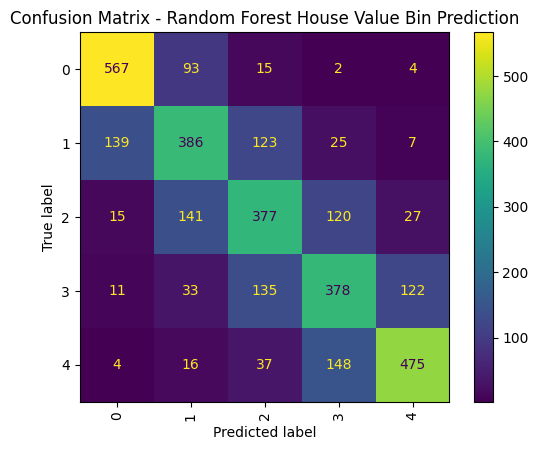

In [59]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

# -----------------------------
# Confusion Matrix
# -----------------------------
cm = confusion_matrix(
y_test, y_pred
)

# The actual classes from y_test and y_pred are 0-4 (5 classes).
# The classification report confirms classes 0, 1, 2, 3, 4.
# We need to ensure display_labels match these 5 classes.
# Since encoder.classes_ was found to be incorrectly large (3694),
# we will use a range corresponding to the 5 bins.
display_labels = np.arange(cm.shape[0]) # This will be [0, 1, 2, 3, 4]

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=display_labels
)

plt.figure(figsize=(12, 12))
disp.plot(xticks_rotation=90, cmap=None)
plt.title("Confusion Matrix - Random Forest House Value Bin Prediction")
plt.show()

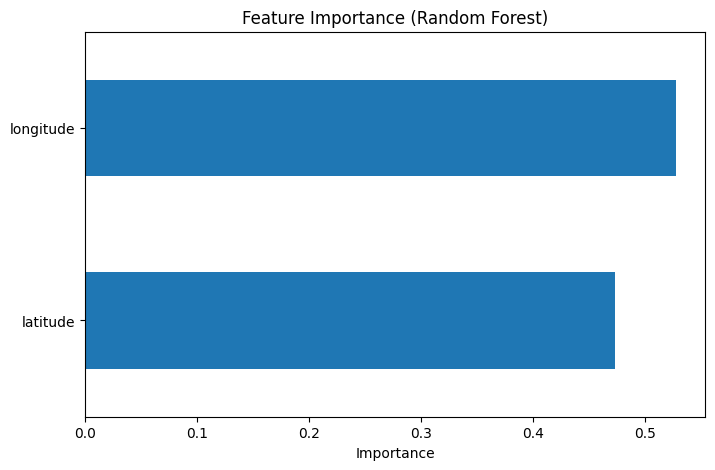

In [60]:
import matplotlib.pyplot as plt

importances.sort_values().plot(kind="barh", figsize=(8, 5))
plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()


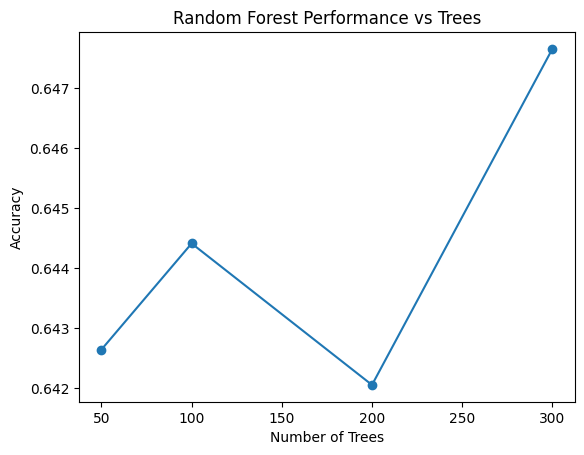

In [61]:
scores = []
trees = [50, 100, 200, 300]

for n in trees:
    rf = RandomForestClassifier(n_estimators=n, random_state=42, n_jobs=-1)
    rf.fit(X_train, y_train)
    scores.append(rf.score(X_test, y_test))

plt.plot(trees, scores, marker="o")
plt.xlabel("Number of Trees")
plt.ylabel("Accuracy")
plt.title("Random Forest Performance vs Trees")
plt.show()
